In [1]:
!pip install ~/fwiVis/utility_functions/
! pip install plotnine

Processing /home/jovyan/fwiVis/utility_functions
  Preparing metadata (setup.py) ... done
  DEPRECATION: Building 'fwiVis' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'fwiVis'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Created wheel for fwiVis: filename=fwivis-0.1-py3-none-any.whl size=19557 sha256=92e556a88c6631d935184642ee2f72f8b78852569e08e96c5669e32e9c947350
  Stored in directory: /tmp/pip-ephem-wheel-cache-xtpudkoo/wheels/79/0f/3d/08c18473dd7e0fb915900e6b4f13b81f1fa84371f9bf24d864
Successfully built fwiVis
  Attempting uninstall: fwiVis
    Found existing installation: fwiVis 0.1
    Uninstalling fwiVis-0.1:
      Successfully uninstalled fwiVis-0.1


In [2]:
#import fwiVis.fwiVis as fv
import s3fs
s3 = s3fs.S3FileSystem(anon=False)
from math import cos, asin, sqrt
import re

import numpy as np
import geopandas as gpd
import pandas as pd
#from matplotlib import pyplot as plt
import os
import rioxarray as rio
import xarray as xr
import rasterio
import glob
from shapely.errors import ShapelyDeprecationWarning
from shapely.geometry import Point
import warnings
import folium
import datetime
import time
from folium import plugins
warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning) 
warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning) 
import contextily as cx
from shapely.geometry import box
import shapely
import sys
from datetime import datetime, timedelta
from itertools import chain

from datetime import date


sys.path.insert(0, '/projects/old_shared/fire_weather_vis/base-fwi-vis/')
import fwiVis.fwiVis as fv

In [3]:
# path = "/projects/old_shared/fire_weather_vis/Lightning_analysis/fwi_timeline_merge/Quebec_all_fires_merged_together_plus_area_fix_09042024.csv" # Fires with merge fix + chaining fires fix + fires alseep fix
# fires = fv.prep_fire_files(path, crs = "4326")

#fires = gpd.read_file("~/fireatlast_nrt/fireatlas/data/FEDSoutput-v3/Quebec_V3/2023/CombinedLargefire/20230915PM/lf_perimeter.fgb")

fires_feds = fv.formatting_read_in('data/Quebec_v3_full_data_perimeters20241112.csv', start_time = '2023-05-31 00:00:00', end_time = '2023-09-15 12:00:00', gen_cols = False, merge_with_ciffc = False, merge_with_nbac = False)
fires_feds_max = fires_feds.groupby("fireID").farea.max()
fires = fv.formatting_read_in('data/Quebec_v3_full_data_perimeters20241112.csv', start_time = '2023-05-31 00:00:00', end_time = '2023-09-15 12:00:00', gen_cols = True, merge_with_ciffc = False, merge_with_nbac = True)
fires_allt = fires = fv.formatting_read_in('data/Quebec_v3_full_data_perimeters20241112.csv', start_time = '2023-05-31 00:00:00', end_time = '2023-09-15 12:00:00', gen_cols = True, merge_with_ciffc = False, merge_with_nbac = True)
print(len(fires.fireID.unique()))

fires = fires.to_crs(4326)
fires_test = fires.copy()

/srv/conda/envs/notebook/lib/python3.12/site-packages/fwiVis/fwiVis.py:1327: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fire3 = fire3.groupby("fireID").apply(chop_fires_at_end).reset_index(drop = True)
Skipping field prov_code: unsupported OGR type: 5
Skipping field prov_name_en: unsupported OGR type: 5
/srv/conda/envs/notebook/lib/python3.12/site-packages/fwiVis/fwiVis.py:1327: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this 

160


In [4]:
# Read in the fire area from the official perimeters

# import os
# import zipfile

# path = '/projects/old_shared/fire_weather_vis/NBAC/'

# os.chdir(path)

# for file in os.listdir('.'):
#     with zipfile.ZipFile(file, 'r') as zip_ref:
#         zip_ref.extractall('.')


# prov = fv.ca_prov()
# prov = prov[prov.prov_name_en == "Quebec"]

# fires = fires.sjoin(prov) 

In [5]:
nbac_only = gpd.read_file(f"{os.path.abspath('contextual_data')}/NBAC/nbac_2023_20240530.shp")

nbac_only = nbac_only[nbac_only.ADMIN_AREA == 'QC']
nbac_only  = nbac_only [(nbac_only.ADJ_HA >= 400) |(nbac_only.POLY_HA >= 400)]

In [6]:
fires = fires.to_crs(nbac_only.crs)
# fires = fires[['fireID', 't', 'geometry','n_pixels',
#        'n_newpixels', 'farea', 'fperim', 'flinelen', 'duration', 'pixden',
#        'meanFRP', 'lon_centroid',
#        'lat_centroid', 'composit_ids', 'rows_edited']]


def get_max_area(df):
    df["unitless_area"] = df.geometry.area
    df = df[df.unitless_area == df.unitless_area.max()]
    return( df[df.t == df.t.max()])

fires = fires.groupby("fireID").apply(get_max_area).reset_index(drop = True)


/tmp/ipykernel_363/1964064624.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fires = fires.groupby("fireID").apply(get_max_area).reset_index(drop = True)


In [7]:
fires = fires[['mergeid', 'ftype', 'n_pixels', 'n_newpixels', 'farea', 'fperim',
       'flinelen', 'duration', 'pixden', 'meanFRP', 't', 't_st', 't_ed',
       'fireID', 'isignition', 't_inactive', 'isactive', 'isdead',
       'mayreactivate', 'geom_counts', 'low_confidence_grouping', 'region',
       'primarykey', 'geometry']]

fires = fires.to_crs(nbac_only.crs)
nbac = nbac_only.sjoin(fires)
fires = fires.to_crs("4326")

In [8]:

nbac = nbac[(nbac.HS_SDATE < "2023-09-15" ) |  (nbac.AG_SDATE < "2023-09-15")]


In [9]:
print(len(nbac.NFIREID.unique())) ## Intersection.

print(len(nbac_only.NFIREID.unique())) ### 4 in NBAC not in FEDS
print(len(fires.fireID.unique())) ## Intersection





print(f"Per-fire Comparison of Area between Fire Events Suite (FEDS) data and Canadian National Burned Area Composite (NBAC) data. Red line shows 1:1 line.  FEDs tracked {len(fires_feds.fireID.unique())} fires total. NBAC tracked {len(nbac_only.NFIREID.unique())} fires total. {len(fires.fireID.unique())} of the FEDS perimeters overlapped with {len(nbac.NFIREID.unique())} of the NBAC perimeters. FEDS assigned fireIDs to {len(fires_feds.fireID.unique()) - len(fires.fireID.unique())} fires not found in the NBAC. Some were likely false positives associated with built infrastructure or water bodies. {len(nbac_only.NFIREID.unique()) - len(nbac.NFIREID.unique())} NBAC fires were not present in FEDS, ranging from {round(nbac_only[~nbac_only.NFIREID.isin(nbac.NFIREID.unique())].POLY_HA.min()/100, 2)} km^2 to {round(nbac_only[~nbac_only.NFIREID.isin(nbac.NFIREID.unique())].POLY_HA.max()/100, 2)} km^2. When multiple FEDS ids were associated with a single NBAC perimeters, fire areas were combined. In total, FEDS estimated {round(fires_feds_max.sum(), 2)} km^2 of fire affected area, and NBAC estimated {round(nbac_only.POLY_HA.sum()/100, 2)} km^2 burned area. Where they overlapped, FEDS estimated {round(nbac.groupby("fireID").farea.max().sum(), 2)} km^2 and NBAC {round(nbac.groupby("NFIREID").POLY_HA.max().sum()/100, 2)}.")

112
116
160
Per-fire Comparison of Area between Fire Events Suite (FEDS) data and Canadian National Burned Area Composite (NBAC) data. Red line shows 1:1 line.  FEDs tracked 170 fires total. NBAC tracked 116 fires total. 160 of the FEDS perimeters overlapped with 112 of the NBAC perimeters. FEDS assigned fireIDs to 10 fires not found in the NBAC. Some were likely false positives associated with built infrastructure or water bodies. 4 NBAC fires were not present in FEDS, ranging from 5.47 km^2 to 13.5 km^2. When multiple FEDS ids were associated with a single NBAC perimeters, fire areas were combined. In total, FEDS estimated 50129.46 km^2 of fire affected area, and NBAC estimated 42578.62 km^2 burned area. Where they overlapped, FEDS estimated 50072.47 km^2 and NBAC 42544.19.


In [10]:
## Fires not in nbac

feds_only = fires[~fires.fireID.isin(nbac.fireID)]
print(len(feds_only.fireID.unique()))
print(feds_only.groupby("fireID").farea.max().mean())
#feds_only.explore()



## Small, short (1-4 time periods), and possibly tied to static sources and/or false positives. (2 Water bodies,  1 airport).


### 13 in feds, but not in NBAC

0
nan


In [11]:
nbac_o = nbac_only[~nbac_only.NFIREID.isin(nbac.NFIREID)]
print(len(nbac_o.NFIREID.unique()))
print(nbac_o.groupby("NFIREID").ADJ_HA.max().mean())
#nbac_o.explore() 

## 2 started late enough that it likely wasn't big enough for out analysis. Other 3  all small

4
860.6548700742501


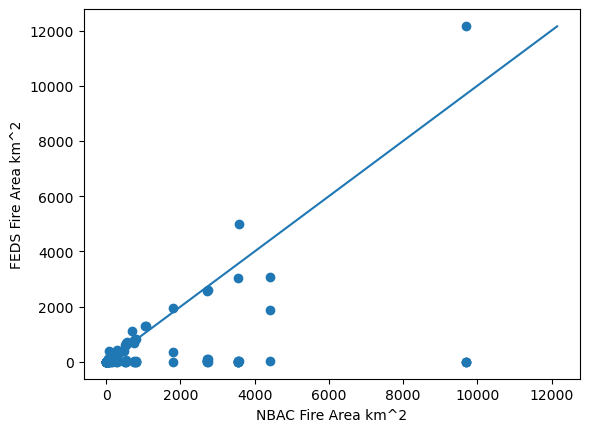

In [12]:
### Look at the fires we agree on. 

import matplotlib.pyplot as plt
seq = range(0, round(nbac.farea.max()), round((nbac.farea.max()/ len(nbac.farea))))

plt.scatter(x = nbac.ADJ_HA/100, y = nbac.farea)
plt.xlabel("NBAC Fire Area km^2")
plt.ylabel("FEDS Fire Area km^2")

plt.plot(seq, seq)

/tmp/ipykernel_363/3597818347.py:25: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  nbac_plot = nbac.groupby("NFIREID").apply(add_small_areas).reset_index(drop = True)


IDs where FEDS tracked multiple fires within one NBAC fire 0


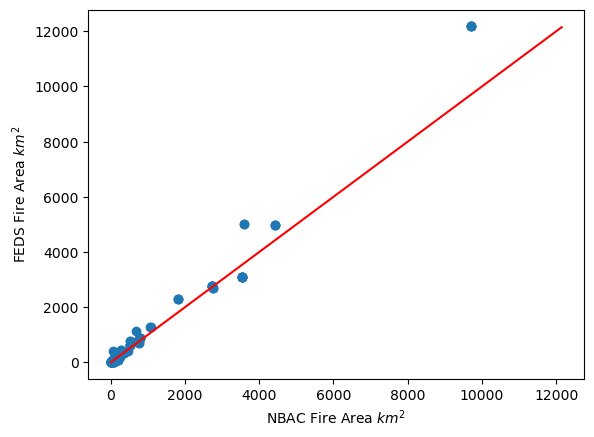

In [13]:
import matplotlib.pyplot as plt



def drop_small_areas(df):
    unique_feds_ids = df.fireID.unique()
    fmax = df.farea.max()
    ## Trying just max to prevent subbing the weird small fires
    fireID = df[df.farea == fmax].fireID.iloc[0]
    df = df[df.fireID == fireID]
    df["max_feds_area"] = df.farea.max()
    return(df)


def add_small_areas(df):
    unique_feds_ids = df.fireID.unique()
    max_fareas = []
    for i in unique_feds_ids:
        max_fareas.append(df[df.fireID == i].farea.max())
    df["sum_feds_area"] = np.sum(max_fareas)
    return(df)

                           
#nbac_plot = nbac.groupby("NFIREID").apply(drop_small_areas).reset_index(drop = True)
nbac_plot = nbac.groupby("NFIREID").apply(add_small_areas).reset_index(drop = True)

print(f'IDs where FEDS tracked multiple fires within one NBAC fire {len(nbac.fireID.unique()) - len(nbac_plot.fireID.unique())}')
seq = range(0, round(nbac_plot.farea.max()), round((nbac_plot.farea.max()/ len(nbac_plot.farea))))

#plt.scatter(x = nbac_plot.ADJ_HA/100, y = nbac_plot.max_feds_area)
plt.scatter(x = nbac_plot.ADJ_HA/100, y = nbac_plot.sum_feds_area)
plt.xlabel("NBAC Fire Area $km^2$")
plt.ylabel("FEDS Fire Area $km^2$")

plt.plot(seq, seq, color = "red")
plt.savefig(f'{os.path.abspath("some_figs/")}/NBAC_compare_plot.png', dpi = 900, transparent = True)
plt.show()




In [14]:
### Check the outliers

def get_area_diff(df):
    unique_feds_ids = df.fireID.unique()
    ## Trying just max to prevent subbing the weird small fires
    df["area_source_diff"] = (df.ADJ_HA/100) - df.farea.max()
    return(df)

#nbac["area_source_diff"] = (nbac.ADJ_HA/100) - (nbac.farea)
nbac = nbac.groupby("NFIREID").apply(get_area_diff).reset_index(drop = True)




plus_10_percent = (nbac.ADJ_HA/100) >= (nbac.farea * 1.1)
minus_10_percent = (nbac.ADJ_HA/100) <= (nbac.farea * 0.9)



bigger_ids = nbac[plus_10_percent].NFIREID.unique() ## 19 larger


nbac = nbac.sort_values(by = "area_source_diff")
bigger_nbac = nbac.groupby("NFIREID").area_source_diff.max().reset_index()
bigger_nbac = bigger_nbac.sort_values(by = "area_source_diff", ascending= False)
bigger_nbac
#bigger_feds = nbac.groupby("NFIREID").area_source_diff.min().reset_index()

/tmp/ipykernel_363/1611368069.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  nbac = nbac.groupby("NFIREID").apply(get_area_diff).reset_index(drop = True)


,NFIREID,area_source_diff
9,347.0,1333.752437
3,341.0,510.751796
1,339.0,163.382629
10,348.0,144.142099
64,533.0,136.481009
...,...,...
5,343.0,-233.640157
0,198.0,-337.011978
6,344.0,-440.775846
7,345.0,-1389.549785


In [15]:
### Looking at totals
print(f"Num fires tracked by feds {len(fires.fireID.unique())}")

tot_nbac = np.sum(nbac_only.ADJ_HA)/100


tot_feds = np.sum(fires.farea)

print(f"NBAC found {tot_nbac}km^2 total fire area. FEDS estimated {tot_feds}")

Num fires tracked by feds 160
NBAC found 42578.61586230361km^2 total fire area. FEDS estimated 50091.189344727565


In [16]:
#?range

In [17]:
# import hvplot.pandas
# hvplot.extension('bokeh')

In [18]:
#plt.scatter(nbac.ADJ_HA/100, nbac.farea)
#plt.ylabel("NBAC Fire Area km^2")
#plt.xlabel("FEDS Fire Area km^2")

#nbac.hvplot.scatter(x = (nbac.ADJ_HA/100), y = nbac.farea)

In [19]:
df = pd.DataFrame(nbac)


In [20]:
nbac.ADJ_HA/100

24    9693.539897
25    9693.539897
23    9693.539897
22    9693.539897
21    3591.308915
         ...     
14    3541.125248
16    3541.125248
26    4414.291620
28    4414.291620
27    4414.291620
Name: ADJ_HA, Length: 163, dtype: float64

In [21]:
# #hvplot.extension('matplotlib')

# df.hvplot.scatter(x = "ADJ_HA", y = "farea", hover_cols=['fireID', 'NFIREID'])

In [22]:
#nbac[(nbac.NFIREID == 346) & (~nbac.fireID.isna())].explore(column = "fireID")

#nbac[(nbac.NFIREID == 346) & (~nbac.fireID.isna())]



In [23]:
# fires_test[fires_test.fireID == '3260'].explore()

# #fires_test.fireID.unique()


In [24]:
#fires[fires.fireID == 2665].explore()

In [25]:
# m = fires_test[fires_test.fireID == '3261'].explore( color = "red")
# nbac[(nbac.NFIREID == '346')].explore(m = m, color = "blue")
# m

In [26]:
nbac[(nbac.NFIREID == 346)].fireID

24    2665
25    3260
23    3261
22     226
Name: fireID, dtype: object

In [27]:
ids = [226, 3261, 2665, 3260]


nbac.loc[(nbac.fireID.isin(ids)), ['NFIREID',
       'HS_SDATE', 'HS_EDATE', 'geometry', 'ftype', 'n_pixels',
       'n_newpixels', 'farea', 'fperim', 'flinelen', 'duration', 'pixden',
       'meanFRP', 't', 't_st', 't_ed', 'fireID', 'isignition', 't_inactive',
       'isactive', 'isdead', 'mayreactivate', 'geom_counts',
       'low_confidence_grouping']]

,NFIREID,HS_SDATE,HS_EDATE,geometry,ftype,n_pixels,n_newpixels,farea,fperim,flinelen,...,t_st,t_ed,fireID,isignition,t_inactive,isactive,isdead,mayreactivate,geom_counts,low_confidence_grouping


In [28]:
nbac.columns

Index(['YEAR', 'NFIREID', 'BASRC', 'FIREMAPS', 'FIREMAPM', 'FIRECAUS',
       'HS_SDATE', 'HS_EDATE', 'AG_SDATE', 'AG_EDATE', 'CAPDATE', 'POLY_HA',
       'ADJ_HA', 'ADJ_FLAG', 'ADMIN_AREA', 'NATPARK', 'PRESCRIBED', 'VERSION',
       'GID', 'geometry', 'index_right', 'mergeid', 'ftype', 'n_pixels',
       'n_newpixels', 'farea', 'fperim', 'flinelen', 'duration', 'pixden',
       'meanFRP', 't', 't_st', 't_ed', 'fireID', 'isignition', 't_inactive',
       'isactive', 'isdead', 'mayreactivate', 'geom_counts',
       'low_confidence_grouping', 'region', 'primarykey', 'area_source_diff'],
      dtype='object')

In [29]:
# m = fires[fires.fireID == 3261].explore( color = "red")
# m = fires[fires.fireID == 2665].explore(m = m,  color = "yellow")
# m = fires[fires.fireID == 3260].explore( m = m, color = "green")
# fires[fires.fireID == 226].explore(m = m)


# Generate text for the results section

In [30]:
biggest_fire = fires[fires.farea == fires.farea.max()].fireID.iloc[0]

In [31]:
print(f" The largest fire burned more than 1M ha over {round(fires[fires.fireID == biggest_fire].duration.max())} days ({round(fires[fires.fireID == biggest_fire].farea.iloc[0])} km^2),  in 2023,")
print(f"and the average final fire size and duration were {round(fires.farea.mean())} km^2 and {round(fires.duration.mean())} days.")

 The largest fire burned more than 1M ha over 78 days (12166 km^2),  in 2023,
and the average final fire size and duration were 311 km^2 and 15 days.


In [32]:
# zones = gpd.read_file(f"{os.path.abspath('contextual_data')}/supression_zones_quebec/Full_response_limit.shp")
# # zones= zones.set_crs(32198)

# # zones = zones.to_crs("4326")

# # zones['geometry'] = shapely.unary_union(zones.geometry)


eco_provs_n = gpd.read_file(f'{os.path.abspath("contextual_data/")}/ecoregions/QC_NorthernEcoregions_LimitedResponseZone.shp')
eco_provs_s = gpd.read_file(f'{os.path.abspath("contextual_data/")}/ecoregions/QC_SouthernEcoregions_FullResponseZone.shp')
eco_provs_n = eco_provs_n.to_crs("4326")
eco_provs_s = eco_provs_s.to_crs("4326")
eco_provs_s['geometry'] = shapely.unary_union(eco_provs_s.geometry)
eco_provs_n['geometry'] = shapely.unary_union(eco_provs_n.geometry)
eco_provs_s.loc[:, 'suppression'] = "IPZ"
eco_provs_n.loc[:, 'suppression'] = "NPZ"
eco_provs = pd.concat([eco_provs_s, eco_provs_n])


fires_zones = fires.sjoin(eco_provs, how = "left")
print(len(fires_zones[~fires_zones.suppression.isna()].fireID.unique()))
# fires_zones = fires_zones.sjoin(eco_provs_n, how = "left")
# print(len(fires_zones[~fires_zones.suppression.isna()].fireID.unique()))

160


In [33]:
# import lonboard
# from lonboard import Map, PolygonLayer

# layer = PolygonLayer(
#     # Select only a few attribute columns from the table
#     table=zones
# )

# m = Map(layer)
# m

In [34]:
print(f"Intensive Protection Zone in southern Quebec are actively suppressed and therefore smaller, on average ({round(fires_zones[fires_zones.suppression=='IPZ'].farea.mean())} km^2),")

print(f"whereas fires in the Northern Protection Zone may be monitored but allowed to burn or receive modified suppression to protect structures or critical infrastructure (On average {round(fires_zones[fires_zones.suppression=='NPZ'].farea.mean())} km^2).")

Intensive Protection Zone in southern Quebec are actively suppressed and therefore smaller, on average (254 km^2),
whereas fires in the Northern Protection Zone may be monitored but allowed to burn or receive modified suppression to protect structures or critical infrastructure (On average 371 km^2).


In [35]:
#print(f"Additionally, fires in the Northern Protection Zone lasted longer and burned later into the season than fires in the Intensive Protection Zone, with a median duration of {round(fires_zones[fires_zones.suppression=='NPZ'].duration.mean())} in the NPZ and {round(fires_zones[fires_zones.suppression=='IPZ'].duration.mean())} in the IPZ.")


print(f"Additionally, fires in the Northern Protection Zone lasted longer and burned later into the season than fires in the Intensive Protection Zone, with a maximum duration of {round(fires_zones[fires_zones.suppression=='NPZ'].duration.max())} in the NPZ and {round(fires_zones[fires_zones.suppression=='IPZ'].duration.max())} in the IPZ.")



Additionally, fires in the Northern Protection Zone lasted longer and burned later into the season than fires in the Intensive Protection Zone, with a maximum duration of 78 in the NPZ and 39 in the IPZ.


In [36]:
round(fires_zones[fires_zones.suppression=='IPZ'].duration.max())

round(fires_zones[fires_zones.suppression=='NPZ'].duration.max())

78

In [37]:
fires_zones[fires_zones.duration == 0].fireID.unique()

array(['231'], dtype=object)